In [17]:
import librosa
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [18]:
# Loading du dataset avec librosa
def load_dataset(data_dir='data', sr=22050, target_len=22050*5):
    x, y = [], []
    for label in sorted(os.listdir(data_dir)):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue

        for file in os.listdir(label_dir):
            if not file.lower().endswith('.wav'):
                continue

            file_path = os.path.join(label_dir, file)
            audio, _ = librosa.load(file_path, sr=sr)

            # Ensure fixed length for stacking into a 2D array
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))
            else:
                audio = audio[:target_len]

            x.append(audio.astype(np.float32))
            y.append(label)

    if not x:
        raise ValueError(f'No .wav files found in {data_dir}')

    x = np.stack(x)
    y = np.array(y)
    return x, y

x, y = load_dataset('data')

df = pd.DataFrame()
df['sound'] = list(x)  # Store each audio sample as a list element
df['label'] = y
print('x shape:', x.shape)
print('y shape:', y.shape)
print('classes:', np.unique(y))

x shape: (1211, 110250)
y shape: (1211,)
classes: ['Bronchial' 'asthma' 'copd' 'healthy' 'pneumonia']


In [11]:
df.head()

,sound,label
0,"[0.00341448, 0.00590638, 0.0069539696, 0.00855...",Bronchial
1,"[-0.024567118, -0.036486607, -0.033269316, -0....",Bronchial
2,"[0.00089291716, 0.0012487946, 0.0011123628, 0....",Bronchial
3,"[0.0073115397, 0.010985471, 0.009617966, 0.010...",Bronchial
4,"[-0.0039379024, -0.002399697, 0.002469554, 0.0...",Bronchial


Text(0.5, 1.0, 'Distribution des classes')

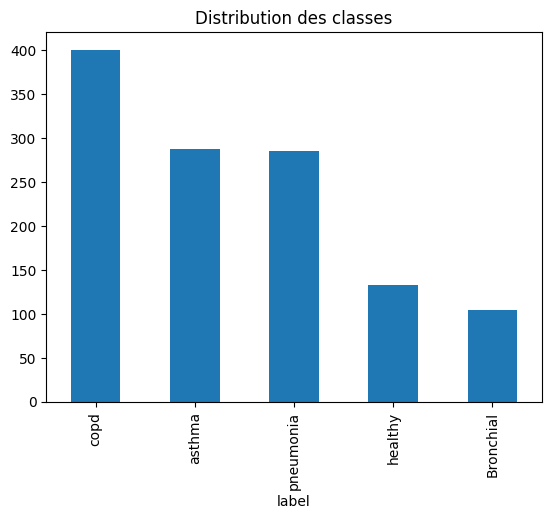

In [19]:
# Graphique de distribution des classes
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution des classes')

In [ ]:
# 

Forme de x: (1211, 110250)
Forme de y: (1211,)
